In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path
from scipy.stats import gaussian_kde
import time

import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import zuko

import utils

In [125]:
def permutation_importance_full(flow, X, Y, feature_names, device, n=1000, n_repeats=15):
    """
    NLL-based permutation importance over ALL features.

    Uses n_repeats independent permutations to estimate mean and std.

    Parameters
    ----------
    flow       : trained zuko NSF
    X          : tensor of shape (N, n_feats) — standardized test features
    Y          : tensor of shape (N, 2)       — standardized log-transformed targets
    feature_names : list of str, length n_feats
    device     : device on which we want to work
    n          : number of test samples to use
    n_repeats  : number of independent permutations per feature (Fisher et al. §3)

    Returns
    -------
    means : pd.Series  — mean NLL increase per feature
    stds  : pd.Series  — std of NLL increase (used for error bars)
    plots with error bars
    """
    flow.eval()
    idx = torch.randperm(len(X))[:n]
    Xp = X[idx].clone()
    Yp = Y[idx]
    Xp = Xp.to(device)
    Yp = Yp.to(device)

    with torch.no_grad():
        base_nll = -flow(Xp).log_prob(Yp).mean().item()

    results = {}
    for k, feat in enumerate(feature_names):
        deltas = []
        for _ in range(n_repeats):
            Xp_perm = Xp.clone()
            # Independently permute only column k
            Xp_perm[:, k] = Xp[torch.randperm(len(Xp)), k]
            with torch.no_grad():
                perm_nll = -flow(Xp_perm).log_prob(Yp).mean().item()
            deltas.append(perm_nll - base_nll)
        results[feat] = (np.mean(deltas), np.std(deltas))

    means = pd.Series({k: v[0] for k, v in results.items()})
    stds  = pd.Series({k: v[1] for k, v in results.items()})

    # Plot with error bars
    order = means.sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(order.index, order.values,
            xerr=stds[order.index].values, capsize=4,
            color=['steelblue' if v > 0 else 'lightgray' for v in order.values])
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel("Mean ΔNLL", fontsize=11)
    ax.set_title("Permutation Feature Importance — All Context Features\n"
                 f"({n_repeats} permutation trials, error bars = ±1 std)", fontsize=12)
    plt.tight_layout()
    plt.show()
    return means, stds


# Flood

In [126]:
DATASET_PATH = Path("../datasets/disasters_merged_all_feats.csv")
EVENT_GROUP = 'Flood'
RUN_PATH = Path(f"../runs/best_flow_{EVENT_GROUP.lower()}.pt")

### Data preparation

In [127]:
df = pd.read_csv(DATASET_PATH)

In [128]:
event_group_dfs = {
    'Hail': df[df['EVENT_GROUP'] == 'Hail'].drop(columns=['EVENT_GROUP', 'WIND_SPEED']),
    'Wind': df[df['EVENT_GROUP'] == 'Wind'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Storm': df[df['EVENT_GROUP'] == 'Storm'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Flood': df[df['EVENT_GROUP'] == 'Flood'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Freeze': df[df['EVENT_GROUP'] == 'Freeze'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Drought': df[df['EVENT_GROUP'] == 'Drought'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Snow': df[df['EVENT_GROUP'] == 'Snow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heat': df[df['EVENT_GROUP'] == 'Heat'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heavy Rain': df[df['EVENT_GROUP'] == 'Heavy Rain'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Fog': df[df['EVENT_GROUP'] == 'Fog'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Wildfire': df[df['EVENT_GROUP'] == 'Wildfire'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Lightning': df[df['EVENT_GROUP'] == 'Lightning'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Debris Flow': df[df['EVENT_GROUP'] == 'Debris Flow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Avalanche': df[df['EVENT_GROUP'] == 'Avalanche'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
}

In [129]:
df = event_group_dfs[EVENT_GROUP]

In [130]:
TARGET_COLS = ["DAMAGES", "CASUALTIES"]

X_COLS = [
    'BEGIN_LAT', 'BEGIN_LON',
    'DURATION_HOURS', 'WIND_SPEED', # change with hail size for hail
    'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM',
    'PRECIPITATION', 'TMIN', 'TMAX',
    'ELEVATION', 'SLOPE',
    'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION',
    'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN',
    'RIVER_DISTANCE', 'SEA_DISTANCE'
]

In [131]:
X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

In [132]:
# targets log transformation
Y = np.log1p(Y)

In [133]:
# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

In [134]:
# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)


In [135]:
# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

In [136]:
# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)

### Model

In [137]:
EPOCHS = 200
LEARNING_RATE = 1e-3
BATCH_SIZE = 256

In [138]:
X_DIM = X_train.shape[1]
Y_DIM = 2   # DAMAGES, CASUALTIES

flow = zuko.flows.NSF(
    features=Y_DIM,
    context=X_DIM,
    transforms=8,
    hidden_features=[256, 256, 256],
    bins=16
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"NSF model created with {sum(p.numel() for p in flow.parameters())} parameters")

NSF model created with 1295088 parameters


In [139]:
test_loader   = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [140]:
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"Model moved to {device}")

Model moved to cuda


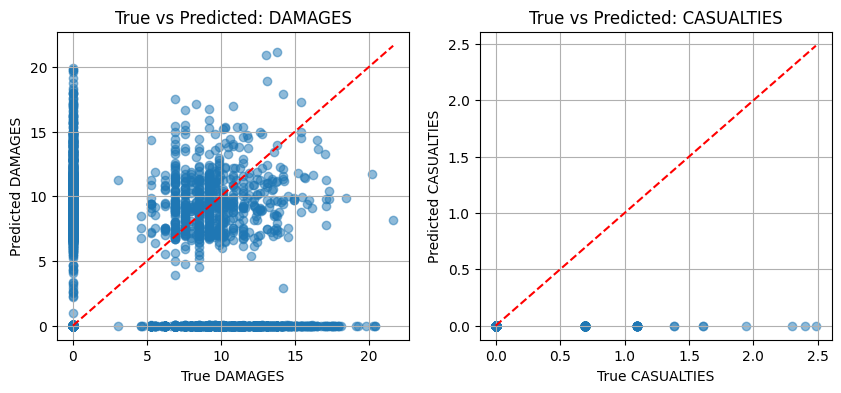

In [141]:
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

## Feature importance analysis

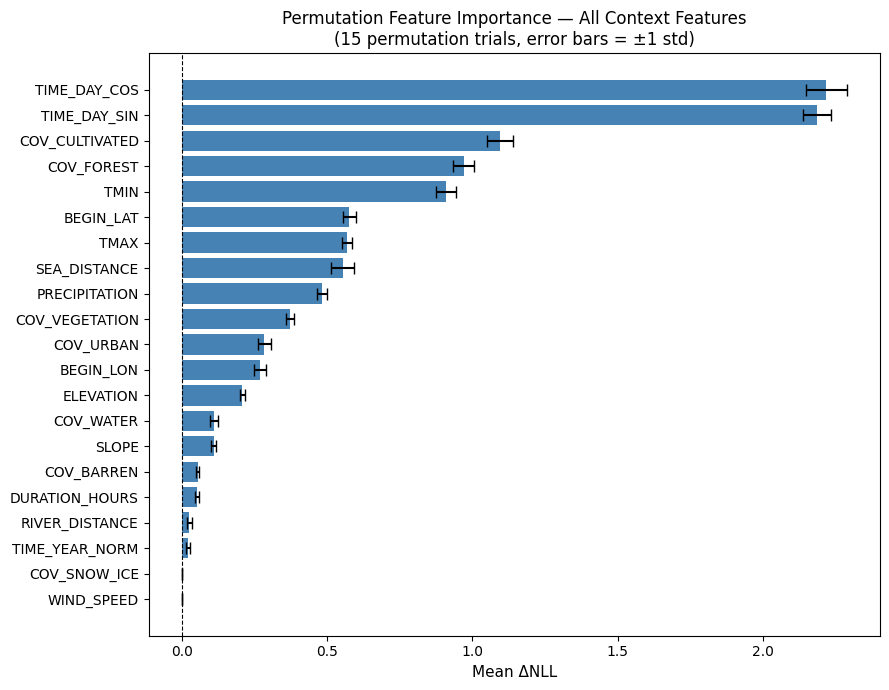

(BEGIN_LAT         0.575320
 BEGIN_LON         0.268317
 DURATION_HOURS    0.052566
 WIND_SPEED        0.000000
 TIME_DAY_SIN      2.186676
 TIME_DAY_COS      2.218312
 TIME_YEAR_NORM    0.019403
 PRECIPITATION     0.482479
 TMIN              0.908290
 TMAX              0.568792
 ELEVATION         0.207357
 SLOPE             0.108735
 COV_BARREN        0.053570
 COV_CULTIVATED    1.094687
 COV_VEGETATION    0.372512
 COV_FOREST        0.970275
 COV_WATER         0.109953
 COV_SNOW_ICE      0.000102
 COV_URBAN         0.283366
 RIVER_DISTANCE    0.024803
 SEA_DISTANCE      0.553456
 dtype: float64,
 BEGIN_LAT         0.022421
 BEGIN_LON         0.020005
 DURATION_HOURS    0.007278
 WIND_SPEED        0.000000
 TIME_DAY_SIN      0.048484
 TIME_DAY_COS      0.070935
 TIME_YEAR_NORM    0.006785
 PRECIPITATION     0.017683
 TMIN              0.034122
 TMAX              0.018480
 ELEVATION         0.008232
 SLOPE             0.009476
 COV_BARREN        0.006236
 COV_CULTIVATED    0.044475
 CO

In [142]:
permutation_importance_full(flow, X_test, Y_test, X_COLS, device)

# Storm

In [22]:
DATASET_PATH = Path("../datasets/disasters_merged_all_feats.csv")
EVENT_GROUP = 'Storm'
RUN_PATH = Path(f"../runs/best_flow_{EVENT_GROUP.lower()}.pt")

### Data preparation

In [ ]:
df = pd.read_csv(DATASET_PATH)
event_group_dfs = {
    'Hail': df[df['EVENT_GROUP'] == 'Hail'].drop(columns=['EVENT_GROUP', 'WIND_SPEED']),
    'Wind': df[df['EVENT_GROUP'] == 'Wind'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Storm': df[df['EVENT_GROUP'] == 'Storm'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Flood': df[df['EVENT_GROUP'] == 'Flood'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Freeze': df[df['EVENT_GROUP'] == 'Freeze'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Drought': df[df['EVENT_GROUP'] == 'Drought'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Snow': df[df['EVENT_GROUP'] == 'Snow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heat': df[df['EVENT_GROUP'] == 'Heat'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heavy Rain': df[df['EVENT_GROUP'] == 'Heavy Rain'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Fog': df[df['EVENT_GROUP'] == 'Fog'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Wildfire': df[df['EVENT_GROUP'] == 'Wildfire'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Lightning': df[df['EVENT_GROUP'] == 'Lightning'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Debris Flow': df[df['EVENT_GROUP'] == 'Debris Flow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Avalanche': df[df['EVENT_GROUP'] == 'Avalanche'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
}
df = event_group_dfs[EVENT_GROUP]
TARGET_COLS = ["DAMAGES", "CASUALTIES"]

X_COLS = [
    'BEGIN_LAT', 'BEGIN_LON',
    'DURATION_HOURS', 'WIND_SPEED', # change with hail size for hail
    'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM',
    'PRECIPITATION', 'TMIN', 'TMAX',
    'ELEVATION', 'SLOPE',
    'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION',
    'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN',
    'RIVER_DISTANCE', 'SEA_DISTANCE'
]
X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)
# targets log transformation
Y = np.log1p(Y)
# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)
# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)

# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

### Model

NSF model created with 1295088 parameters
Model moved to cuda


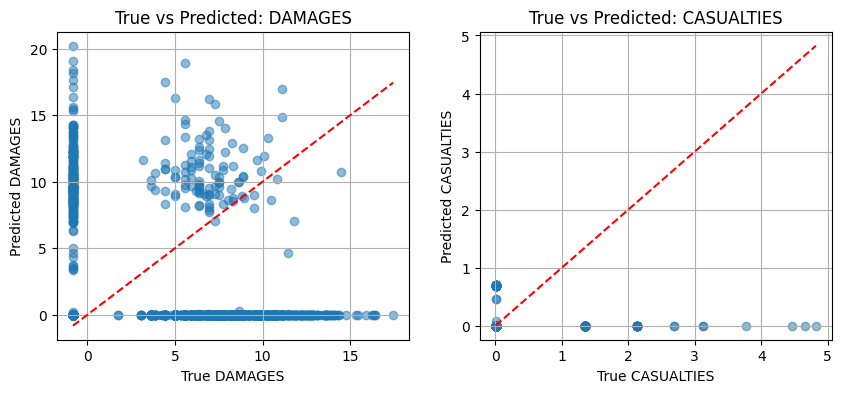

In [25]:
EPOCHS = 200
LEARNING_RATE = 1e-3
BATCH_SIZE = 256
X_DIM = X_train.shape[1]
Y_DIM = 2   # DAMAGES, CASUALTIES

flow = zuko.flows.NSF(
    features=Y_DIM,
    context=X_DIM,
    transforms=8,
    hidden_features=[256, 256, 256],
    bins=16
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"NSF model created with {sum(p.numel() for p in flow.parameters())} parameters")
test_loader   = DataLoader(test_ds, batch_size=BATCH_SIZE)
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"Model moved to {device}")
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

## Feature importance analysis